In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
%matplotlib inline

In [91]:
words = open("names.txt").read().splitlines()
print(len(words))
words[:10]

32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [92]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [93]:
# build dataset
block_size = 3  #context length, how many characters dfo we take to predict the next character

def build_dataset(items):
  x_temp = []
  y_temp = []
  for w in items:
    context = [0] * block_size  #???
    for ch in w + '.':
      ix = stoi[ch]
      x_temp.append(context)
      y_temp.append(ix)
      # print(''.join(itos[i] for i in context), "--->", itos[ix])
      context = context[1:] + [ix]  # crop and append
  return torch.tensor(x_temp), torch.tensor(y_temp)

import random
random.seed(42)
random.shuffle(words)
n = len(words)
x_train, y_train = build_dataset(words[:int(0.8*n)])
x_dev, y_dev = build_dataset(words[int(0.8*n):int(0.9*n)])
x_test, y_test = build_dataset(words[int(0.9*n):])

x_train.shape, y_train.shape, x_dev.shape, y_dev.shape, x_test.shape, y_test.shape


(torch.Size([182625, 3]),
 torch.Size([182625]),
 torch.Size([22655, 3]),
 torch.Size([22655]),
 torch.Size([22866, 3]),
 torch.Size([22866]))

In [94]:
lre = torch.linspace(-3, 0, 100)
lrs = 10**lre
lrs

tensor([0.0010, 0.0011, 0.0011, 0.0012, 0.0013, 0.0014, 0.0015, 0.0016, 0.0017,
        0.0019, 0.0020, 0.0022, 0.0023, 0.0025, 0.0027, 0.0028, 0.0031, 0.0033,
        0.0035, 0.0038, 0.0040, 0.0043, 0.0046, 0.0050, 0.0053, 0.0057, 0.0061,
        0.0066, 0.0071, 0.0076, 0.0081, 0.0087, 0.0093, 0.0100, 0.0107, 0.0115,
        0.0123, 0.0132, 0.0142, 0.0152, 0.0163, 0.0175, 0.0187, 0.0201, 0.0215,
        0.0231, 0.0248, 0.0266, 0.0285, 0.0305, 0.0327, 0.0351, 0.0376, 0.0404,
        0.0433, 0.0464, 0.0498, 0.0534, 0.0572, 0.0614, 0.0658, 0.0705, 0.0756,
        0.0811, 0.0870, 0.0933, 0.1000, 0.1072, 0.1150, 0.1233, 0.1322, 0.1417,
        0.1520, 0.1630, 0.1748, 0.1874, 0.2009, 0.2154, 0.2310, 0.2477, 0.2656,
        0.2848, 0.3054, 0.3275, 0.3511, 0.3765, 0.4037, 0.4329, 0.4642, 0.4977,
        0.5337, 0.5722, 0.6136, 0.6579, 0.7055, 0.7565, 0.8111, 0.8697, 0.9326,
        1.0000])

In [104]:
g = torch.Generator().manual_seed(2147483647)
#F.one_hot(torch.tensor(5), num_classes=27).float() @ C
C = torch.randn((27, 10), requires_grad=True, generator=g)
W1 = torch.randn((30, 200), requires_grad=True, generator=g)
b1 = torch.randn(200, requires_grad=True, generator=g)
W2 = torch.randn((200, 27), requires_grad=True, generator=g)
b2 = torch.randn(27, requires_grad=True, generator=g)
parameters = [C, W1, b1, W2, b2]
print('number of parameters:', sum(p.nelement() for p in parameters))
BATCH_SIZE = 32


number of parameters: 11897


In [107]:
lossi = []
stepi = []

probs =  tensor([0.1648, 0.0998, 0.0049, 0.0236, 0.0197, 0.0402, 0.0036, 0.0169, 0.0076,
        0.0180, 0.0019, 0.0084, 0.1388, 0.0353, 0.1568, 0.0076, 0.0062, 0.0031,
        0.0824, 0.0413, 0.0377, 0.0178, 0.0181, 0.0044, 0.0033, 0.0250, 0.0129])
Final Loss =  2.2719552516937256


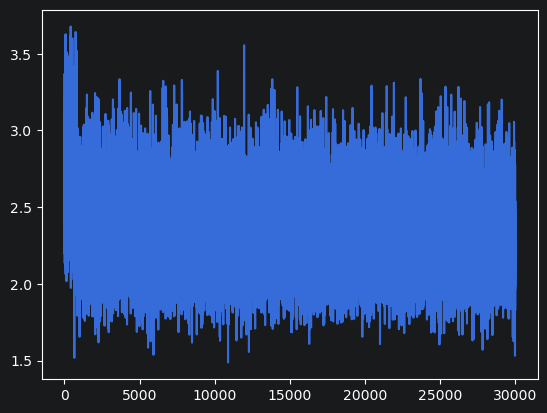

In [108]:
# training loop
for i in range(30000):
  # minibatch of 32
  ix = torch.randint(0, x_train.shape[0], (BATCH_SIZE,), generator=g)
  Xb, Yb = x_train[ix], y_train[ix]
  emb = C[Xb]
  z = emb.view(-1, 30)
  h = torch.tanh(z @ W1 + b1)
  logits = h @ W2 + b2
  # probs = F.softmax(logits, dim=1)
  # loss = -torch.log(probs[torch.arange(BATCH_SIZE), Yb]).mean()
  loss = F.cross_entropy(logits, Yb)   # Yb shape (B,)
  # print(i, loss.item())
  # set grad to 0, zero_grad()
  for p in [C, W1, b1, W2, b2]:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 800 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.item())

# softmax activation
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# built-in softmax

print('probs = ', probs)

print('Final Loss = ', loss.item())

# computes all gradients
for p in parameters:
  p.data -= 0.1 * p.grad

plt.plot(stepi, lossi)

In [97]:
emb = C[x_dev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # shape ()
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_dev)
loss

tensor(2.4635, grad_fn=<NllLossBackward0>)

In [98]:
emb = C[x_test]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # shape ()
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_test)
loss

tensor(2.4675, grad_fn=<NllLossBackward0>)

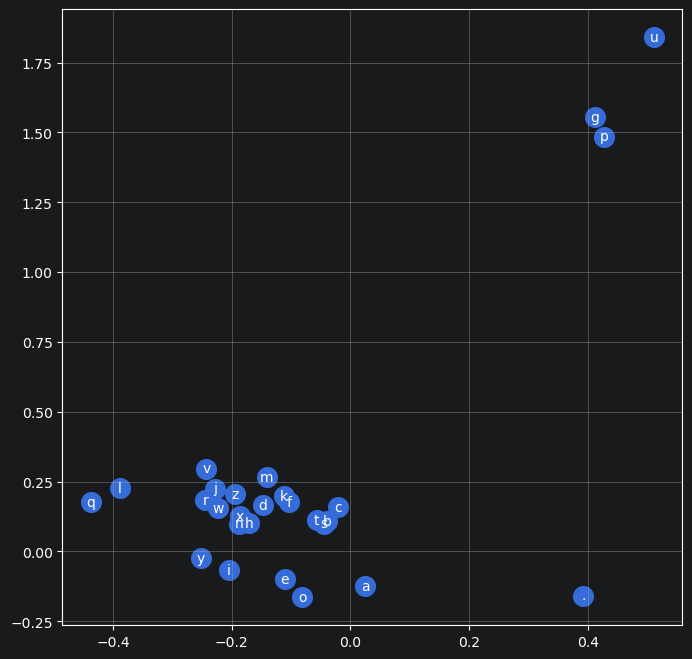

In [99]:
# visualize the chars
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')


In [100]:
# ---- inference: next-char prediction for a 3-char context ----
@torch.no_grad()
def predict_next_char(context3):
    # context3 must have length 3
    x = torch.tensor([[stoi[c] for c in context3]], dtype=torch.long)  # (1,3)
    emb = C[x]                       # (1,3,2)
    z = emb.view(1, 6)               # (1,6)
    h = torch.tanh(z @ W1 + b1)      # (1,100)
    logits = h @ W2 + b2             # (1,27)
    probs = F.softmax(logits, dim=1) # (1,27)
    ix = torch.argmax(probs, dim=1).item()
    return itos[ix], probs[0]

ch, probs = predict_next_char("the")
print("predicted next char:", ch)

# ---- optional: generate a word ----
@torch.no_grad()
def generate_one():
    context = [0] * 3
    out = []
    while True:
        x = torch.tensor([context], dtype=torch.long)   # (1,3)
        emb = C[x]
        z = emb.view(1, 6)
        h = torch.tanh(z @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if ix == 0:   # '.' token
            break
        out.append(itos[ix])
    return "".join(out)

print(generate_one())

predicted next char: .
lya
